# House Prices Regression - Modelling

## 1. Modelling Overview

This notebook focuses on preparing the data and training Machine Learning models to predict house sale prices.

The main steps include data cleaning, feature engineering, preprocessing, model training, model comparison, hyperparameter tuning and final evaluation.

The train-test split will be recreated using the same random state used in the EDA notebook to ensure consistency.

The test set will remain untouched until the final evaluation stage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import importlib
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
sys.path.append('../src')

In [2]:
from feature_engineering import create_features
from feature_engineering import evaluate_model_cv

## 2. Load Dataset

The original dataset is loaded from the raw data folder.

No transformations are applied at this stage.

In [3]:
df = pd.read_csv("../input/AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
df.shape

(2930, 82)

## 3. Train-Test Split

The dataset is split into training and test sets before any preprocessing step.

The training set will be used for data cleaning, feature engineering, preprocessing and model training.

The test set will only be used at the end to evaluate the final selected model.

In [5]:
target = 'SalePrice'
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2344, 81)
X_test shape: (586, 81)
y_train shape: (2344,)
y_test shape: (586,)


In [6]:
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()
y_train_clean = y_train.copy()
y_test_clean = y_test.copy()

print(f"X_train_clean shape: {X_train_clean.shape}")
print(f"X_test_clean shape: {X_test_clean.shape}")

X_train_clean shape: (2344, 81)
X_test_clean shape: (586, 81)


## 4. Initial Modelling Checklist

Before training models, the following steps must be performed:

1. Remove unnecessary identifier columns
2. Handle potential outliers in the training data
3. Treat missing values
4. Create engineered features
5. Encode categorical variables
6. Scale numerical variables when needed
7. Train a baseline model
8. Compare multiple regression models
9. Tune the best model
10. Evaluate the final model on the test set

## 5. Data Cleaning

In this section, we start cleaning the dataset before model training.

The first step is to remove identifier columns that do not provide predictive information for the model.

Columns such as `Order` and `PID` are useful for identifying records, but they should not be used as input features for machine learning models.

In [7]:
identifier_columns = ['Order', 'PID']
[col for col in identifier_columns if col in X_train_clean.columns]

['Order', 'PID']

In [8]:
X_train_clean = X_train_clean.drop(columns=identifier_columns)
X_test_clean = X_test_clean.drop(columns=identifier_columns)

print(f"X_train_clean shape: {X_train_clean.shape}")
print(f"X_test_clean shape: {X_test_clean.shape}")

X_train_clean shape: (2344, 79)
X_test_clean shape: (586, 79)


In [9]:
[col for col in identifier_columns if col in X_train_clean.columns]

[]

### 5.1 Outlier Treatment

Based on the EDA, some observations with extremely high `Gr Liv Area` may behave as outliers.

These observations can strongly influence regression models, especially linear models.

Outliers will be removed only from the training set.  
The test set will remain untouched to represent unseen real-world data.

In [10]:
train_clean_check = X_train_clean.copy()
train_clean_check["SalePrice"] = y_train_clean
gr_liv_area_outliers = train_clean_check[train_clean_check["Gr Liv Area"] > 4000]
gr_liv_area_outliers[
    [
        "Gr Liv Area",
        "SalePrice",
        "Overall Qual",
        "Neighborhood"
    ]
].sort_values(by="Gr Liv Area", ascending=False)

,Gr Liv Area,SalePrice,Overall Qual,Neighborhood
1498,5642,160000,10,Edwards
2180,5095,183850,10,Edwards
1760,4476,745000,10,NoRidge
1767,4316,755000,10,NoRidge


In [11]:
outlier_indexes = X_train_clean[X_train_clean["Gr Liv Area"] > 4000].index
print(f"Number of outliers to remove: {len(outlier_indexes)}")

X_train_clean = X_train_clean.drop(index=outlier_indexes)
y_train_clean = y_train_clean.drop(index=outlier_indexes)

print(f"X_train_clean shape after outlier removal: {X_train_clean.shape}")
print(f"y_train_clean shape after outlier removal: {y_train_clean.shape}")

Number of outliers to remove: 4
X_train_clean shape after outlier removal: (2340, 79)
y_train_clean shape after outlier removal: (2340,)


In [12]:
print(f"X_test_clean shape: {X_test_clean.shape}")
print(f"y_test_clean shape: {y_test_clean.shape}")

X_test_clean shape: (586, 79)
y_test_clean shape: (586,)


### Data Cleaning Notes

The identifier columns `Order` and `PID` were removed because they do not represent meaningful property characteristics for price prediction.

Extreme observations with `Gr Liv Area` greater than 4000 were removed from the training set only. These observations were identified during the EDA as potential outliers that could strongly affect regression models.

The test set was not modified during outlier removal. This is important because the test set must remain untouched until the final evaluation stage.

## 6. Feature Engineering

In this section, new features are created based on the insights from the exploratory data analysis.

The goal is to create variables that better represent property size, age, renovation status, bathroom capacity and the presence of important property characteristics.

The same transformations will be applied to both training and test sets to keep them consistent.

In [13]:
X_train_fe = create_features(X_train_clean)
X_test_fe = create_features(X_test_clean)

print(f"X_train_fe shape: {X_train_fe.shape}")
print(f"X_test_fe shape: {X_test_fe.shape}")

X_train_fe shape: (2340, 87)
X_test_fe shape: (586, 87)


In [14]:
engineered_features = ["TotalSF","HouseAge","RemodAge","TotalBath","HasGarage","HasBasement","HasFireplace","HasPool"]
X_train_fe[engineered_features].head()

,TotalSF,HouseAge,RemodAge,TotalBath,HasGarage,HasBasement,HasFireplace,HasPool
381,2460.0,33,33,2.0,1,1,1,0
834,3139.0,42,42,3.0,1,1,0,0
1898,1224.0,45,45,2.0,1,0,0,0
678,1040.0,60,59,2.0,1,0,0,0
700,2301.0,89,59,2.0,0,1,0,0


In [15]:
same_columns = X_train_fe.columns.equals(X_test_fe.columns)

print(f"Train and test have the same columns: {same_columns}")

Train and test have the same columns: True


In [16]:
train_fe_analysis = X_train_fe.copy()
train_fe_analysis["SalePrice"] = y_train_clean
engineered_corr = train_fe_analysis[engineered_features + ["SalePrice"]].corr()["SalePrice"]
engineered_corr = engineered_corr.sort_values(ascending=False)
engineered_corr

SalePrice       1.000000
TotalSF         0.813423
TotalBath       0.642083
HasFireplace    0.477883
HasGarage       0.224693
HasBasement     0.162707
HasPool         0.068039
RemodAge       -0.529361
HouseAge       -0.554716
Name: SalePrice, dtype: float64

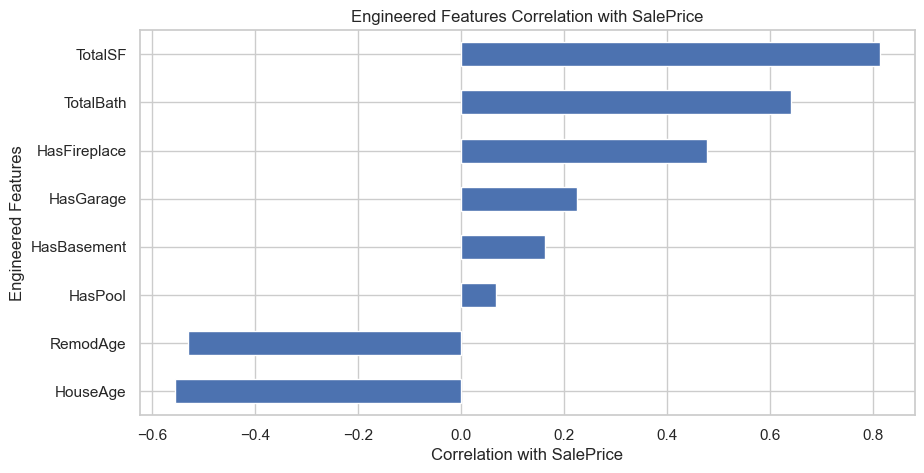

In [17]:
engineered_corr_without_target = engineered_corr.drop("SalePrice")
plt.figure(figsize=(10, 5))
engineered_corr_without_target.sort_values().plot(kind="barh")
plt.title("Engineered Features Correlation with SalePrice")
plt.xlabel("Correlation with SalePrice")
plt.ylabel("Engineered Features")
plt.show()

In [18]:
negative_house_age = (X_train_fe["HouseAge"] < 0).sum()
negative_remod_age = (X_train_fe["RemodAge"] < 0).sum()

print(f"Negative HouseAge values: {negative_house_age}")
print(f"Negative RemodAge values: {negative_remod_age}")

Negative HouseAge values: 0
Negative RemodAge values: 0


### Feature Engineering Notes

New features were created to better represent important property characteristics.

`TotalSF` combines basement area, first floor area and second floor area, representing the overall size of the property.

`HouseAge` and `RemodAge` capture the age of the house and the time since the last remodeling.

`TotalBath` summarizes full and half bathrooms, including basement bathrooms.

Binary features such as `HasGarage`, `HasBasement`, `HasFireplace` and `HasPool` indicate the presence or absence of important house characteristics.

These features will be included in the preprocessing and modeling pipeline.

## 7. Missing Value Treatment

In this section, missing values are handled according to their meaning.

Some missing values represent the absence of a property characteristic, such as no garage, no basement, no fireplace or no pool. These values will be filled with `"None"` for categorical variables or `0` for numerical variables.

Other missing values represent unknown information and will be imputed using statistical strategies such as the median for numerical features or the most frequent value for categorical features.

The imputation strategy will be included in a preprocessing pipeline to avoid data leakage.

In [19]:
missing_train = X_train_fe.isna().sum()
missing_train = missing_train[missing_train > 0]
missing_train = missing_train.sort_values(ascending=False)
missing_train

Pool QC           2330
Misc Feature      2247
Alley             2178
Fence             1871
Mas Vnr Type      1425
Fireplace Qu      1144
Lot Frontage       393
Garage Yr Blt      122
Garage Cond        122
Garage Qual        122
Garage Finish      122
Garage Type        120
Bsmt Exposure       63
BsmtFin Type 2      62
Bsmt Qual           61
BsmtFin Type 1      61
Bsmt Cond           61
Mas Vnr Area        19
BsmtFin SF 1         1
Bsmt Half Bath       1
Garage Cars          1
Garage Area          1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Bsmt Full Bath       1
dtype: int64

In [20]:
categorical_features = X_train_fe.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")

Categorical features: 43
Numerical features: 40


In [21]:
categorical_none_features = ["Pool QC","Misc Feature","Alley","Fence",
    "Fireplace Qu","Garage Type","Garage Finish","Garage Qual",
    "Garage Cond","Bsmt Qual","Bsmt Cond","Bsmt Exposure",
    "BsmtFin Type 1","BsmtFin Type 2","Mas Vnr Type"
]

categorical_none_features = [col for col in categorical_none_features if col in X_train_fe.columns]
categorical_mode_features = [col for col in categorical_features if col not in categorical_none_features]

print(f"Categorical None features: {len(categorical_none_features)}")
print(f"Categorical mode features: {len(categorical_mode_features)}")

Categorical None features: 15
Categorical mode features: 28


In [22]:
numeric_zero_features = ["Mas Vnr Area","Garage Yr Blt","Garage Cars",
    "Garage Area","BsmtFin SF 1","BsmtFin SF 2","Bsmt Unf SF",
    "Total Bsmt SF","Bsmt Full Bath","Bsmt Half Bath"
]

numeric_zero_features = [col for col in numeric_zero_features if col in X_train_fe.columns]
numeric_median_features = [col for col in numerical_features if col not in numeric_zero_features]

print(f"Numeric zero features: {len(numeric_zero_features)}")
print(f"Numeric median features: {len(numeric_median_features)}")

Numeric zero features: 10
Numeric median features: 30


In [23]:
binary_features = ["HasGarage","HasBasement","HasFireplace","HasPool"]
print(f"Binary features: {len(binary_features)}")

Binary features: 4


In [24]:
all_selected_features = (
    categorical_none_features +
    categorical_mode_features +
    numeric_zero_features +
    numeric_median_features +
    binary_features
)

print(f"Total columns in X_train_fe: {X_train_fe.shape[1]}")
print(f"Total selected features: {len(all_selected_features)}")

missing_from_groups = [col for col in X_train_fe.columns if col not in all_selected_features]
missing_from_groups

Total columns in X_train_fe: 87
Total selected features: 87


[]

In [25]:
numeric_zero_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler())
])

numeric_median_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_none_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

categorical_mode_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num_zero", numeric_zero_transformer, numeric_zero_features),
        ("num_median", numeric_median_transformer, numeric_median_features),
        ("cat_none", categorical_none_transformer, categorical_none_features),
        ("cat_mode", categorical_mode_transformer, categorical_mode_features)
    ],

    remainder="drop"
)

In [27]:
X_train_processed = preprocessor.fit_transform(X_train_fe)
X_test_processed = preprocessor.transform(X_test_fe)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

X_train_processed shape: (2340, 317)
X_test_processed shape: (586, 317)


In [28]:
train_missing_after_processing = np.isnan(X_train_processed).sum()
test_missing_after_processing = np.isnan(X_test_processed).sum()

print(f"Missing values in processed training data: {train_missing_after_processing}")
print(f"Missing values in processed test data: {test_missing_after_processing}")

Missing values in processed training data: 0
Missing values in processed test data: 0


### Missing Value Treatment Notes

Missing values were treated according to their meaning.

Categorical variables where missing values indicate absence of a property characteristic were filled with `"None"`.

Numerical variables related to absent structures, such as garage, basement or masonry veneer area, were filled with `0`.

Other numerical variables were imputed using the median, and other categorical variables were imputed using the most frequent category.

All preprocessing steps were included in a `ColumnTransformer`, which ensures that imputation values are learned only from the training data and then applied to the test data.

## 8. Baseline Model

In this section, baseline models are created to establish initial performance references.

The first baseline is a `DummyRegressor`, which predicts the median sale price for every house. This model does not learn any relationship from the features and serves as a naive benchmark.

The second baseline is a `Ridge Regression` model. Ridge is a regularized linear model that helps reduce the impact of multicollinearity and large coefficients.

A standard `LinearRegression` model will not be used as the main linear baseline because the preprocessing step creates many one-hot encoded features. This can increase dimensionality and introduce multicollinearity, making an unregularized linear model less stable.

Therefore, Ridge Regression is used as a stronger and more reliable linear baseline.

In [29]:
dummy_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="median"))
])

In [30]:
dummy_results = evaluate_model_cv(
    dummy_pipeline,
    X_train_fe,
    y_train_clean,
    cv=5
)

dummy_results

{'MAE': 53692.479059829064,
 'RMSE': 77452.25524016068,
 'R2': -0.059035919404605154}

In [31]:
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

In [32]:
ridge_results = evaluate_model_cv(
    ridge_pipeline,
    X_train_fe,
    y_train_clean,
    cv=5
)

ridge_results

{'MAE': 15042.517246454172,
 'RMSE': 21791.57464340359,
 'R2': 0.9157727540455867}

In [33]:
baseline_results = pd.DataFrame({
    "Model": ["Dummy Regressor", "Ridge Regression"],
    "MAE": [dummy_results["MAE"], ridge_results["MAE"]],
    "RMSE": [dummy_results["RMSE"], ridge_results["RMSE"]],
    "R2": [dummy_results["R2"], ridge_results["R2"]]
})

baseline_results = baseline_results.sort_values(by="RMSE", ascending=True)
baseline_results

,Model,MAE,RMSE,R2
1,Ridge Regression,15042.517246,21791.574643,0.915773
0,Dummy Regressor,53692.479060,77452.255240,-0.059036


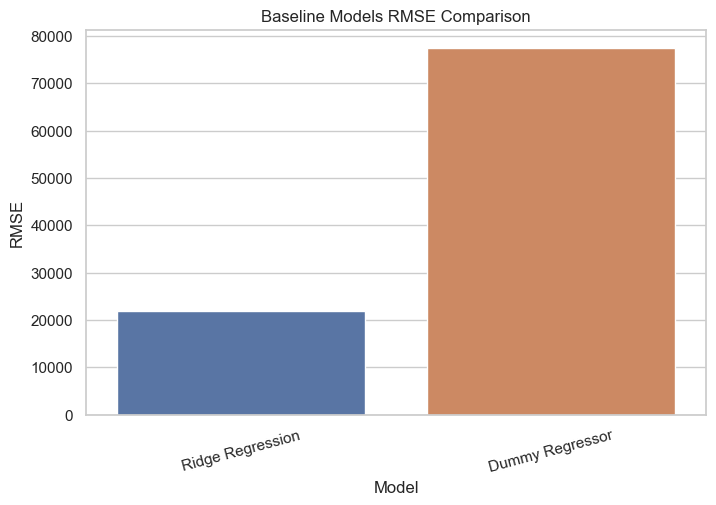

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=baseline_results,
    x="Model",
    y="RMSE"
)
plt.title("Baseline Models RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()

### Baseline Model Notes

The `DummyRegressor` was used as a naive baseline. It predicts the median sale price for every property and does not learn from the input features.

The `LinearRegression` model was intentionally not used as the main linear baseline. After preprocessing, the dataset contains many one-hot encoded categorical variables, which increases dimensionality and may introduce multicollinearity. In this situation, an unregularized linear model can become less stable.

Instead, `Ridge Regression` was selected as the linear baseline because it applies L2 regularization. This helps control large coefficients and makes the model more robust when dealing with many correlated or encoded features.

If Ridge Regression performs significantly better than the Dummy Regressor, it indicates that the dataset contains useful predictive patterns for estimating house prices.

## 9. Model Comparison

In this section, multiple regression models are trained and evaluated using cross-validation.

All models use the same preprocessing pipeline to ensure a fair comparison.

The goal is to identify which models provide the best predictive performance before moving to hyperparameter tuning.